In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore


In [144]:
df = pd.read_csv("C:\\Users\\pc\\Desktop\\Week_0\\climate_challenge_week_0\\data\\ethiopia.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [145]:
df["Country"] = "Ethiopia"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [146]:
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05


In [147]:
df["Month"] = df["Date"].dt.month

df[["Date", "Month"]].head()

,Date,Month
0,2015-01-01,1
1,2015-01-02,1
2,2015-01-03,1
3,2015-01-04,1
4,2015-01-05,1


In [ ]:
# Replace -999 with NaN
df = df.replace(-999, np.nan)

In [150]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [151]:
# Drop duplicates if any
df = df.drop_duplicates()

## Duplicate Analysis

We found 0 duplicate rows in the dataset. Removing duplicates to ensure data integrity before analysis.

In [152]:
# summary statistics
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [153]:
# Check for missing values
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [154]:
# calculate percentage of the missing values
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64

In [155]:
# Identify columns with more than 5% missing values
high_missing = missing_percent[missing_percent > 5]
high_missing

Series([], dtype: float64)

In [ ]:
# select columns for Z-score computation
cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

# Compute Z-scores
z_scores = df[cols].apply(zscore)
z_scores.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-2.286045,-0.163269,-2.603645,-0.577866,-1.806604,1.088524,1.330345
1,-1.985701,0.294724,-2.354311,-0.577866,-2.383500,0.595061,0.547137
2,-1.885586,0.352882,-2.400342,-0.577866,-2.346850,-0.304782,-0.725576
3,-1.047782,0.211122,-1.276418,-0.577866,-2.006821,-1.611007,-2.042790
4,-1.058320,-0.017874,-1.115310,-0.577866,-1.448251,-0.928867,-1.277382


In [158]:
# Indentify outliers (z-score) greater than 3 or less than 3 
outliers = (np.abs(z_scores) > 3)

# Count rows with at least one outlier
outlier_count = outliers.any(axis=1).sum()

outlier_count

np.int64(132)

In [159]:
# Display rows with outliers
df_outliers = df[outliers.any(axis=1)]
df_outliers.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
144,2015,145,18.45,24.94,14.15,10.79,29.07,68.37,1.52,3.07,77.06,11.33,Ethiopia,2015-05-25,5
145,2015,146,17.60,23.52,13.22,10.30,34.38,75.91,1.66,3.53,77.07,11.89,Ethiopia,2015-05-26,5
177,2015,178,15.79,19.03,13.33,5.70,23.89,83.89,1.81,3.03,77.18,12.09,Ethiopia,2015-06-27,6
214,2015,215,15.97,21.06,12.58,8.48,23.46,84.73,1.58,2.55,77.04,12.32,Ethiopia,2015-08-03,8
556,2016,192,15.20,18.00,12.89,5.11,25.19,85.47,1.33,2.99,77.07,11.95,Ethiopia,2016-07-10,7


In [160]:
# Remove rows with more than 30% missing values
threshold = 0.3  # 30%

df = df[df.isna().mean(axis=1) <= threshold]

In [161]:
# Check the shape after removing rows with more than 30% missing values
weather_cols = [
    "T2M", "T2M_MAX", "T2M_MIN",
    "PRECTOTCORR", "RH2M",
    "WS2M", "WS2M_MAX"
]

df[weather_cols] = df[weather_cols].ffill()

In [162]:
# check for missing values after imputation
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [ ]:
# save the cleaned dataset
df.to_csv("data/ethiopia_clean.csv", index=False)

In [165]:
# Ensure Date column is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract Year-Month for grouping
df["YearMonth"] = df["Date"].dt.to_period("M")

monthly_temp = df.groupby("YearMonth")["T2M"].mean().reset_index()

# Convert back to datetime for plotting
monthly_temp["YearMonth"] = monthly_temp["YearMonth"].dt.to_timestamp()

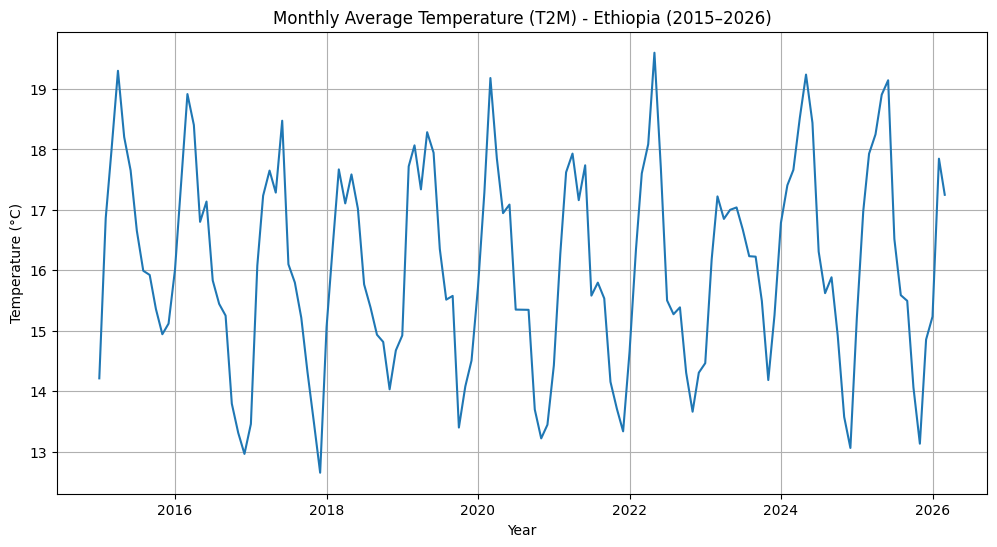

In [166]:
# plotting the monthly average temperature
plt.figure(figsize=(12,6))

plt.plot(monthly_temp["YearMonth"], monthly_temp["T2M"], label="Monthly Avg T2M")

plt.title("Monthly Average Temperature (T2M) - Ethiopia (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.show()

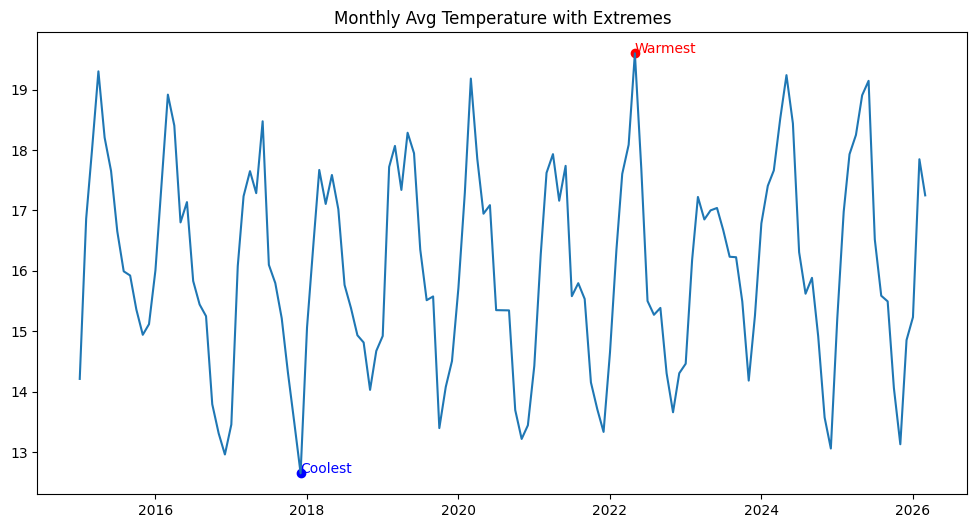

In [167]:
# Identify the warmest and coolest months
warmest = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
coolest = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.figure(figsize=(12,6))
plt.plot(monthly_temp["YearMonth"], monthly_temp["T2M"])

plt.scatter(warmest["YearMonth"], warmest["T2M"], color="red")
plt.scatter(coolest["YearMonth"], coolest["T2M"], color="blue")

plt.text(warmest["YearMonth"], warmest["T2M"], "Warmest", color="red")
plt.text(coolest["YearMonth"], coolest["T2M"], "Coolest", color="blue")

plt.title("Monthly Avg Temperature with Extremes")
plt.show()

In [168]:
# Extract year-month for grouping
monthly_rain = df.groupby("YearMonth")["PRECTOTCORR"].sum().reset_index()
monthly_rain["YearMonth"] = monthly_rain["YearMonth"].dt.to_timestamp()

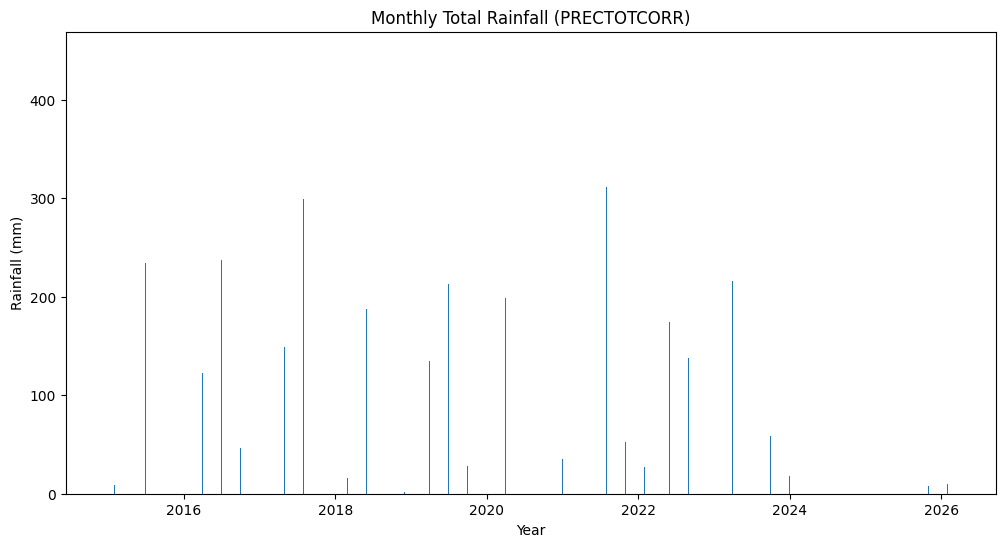

In [169]:
# plotting the monthly total rainfall
plt.figure(figsize=(12,6))

plt.bar(monthly_rain["YearMonth"], monthly_rain["PRECTOTCORR"])

plt.title("Monthly Total Rainfall (PRECTOTCORR)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.show()

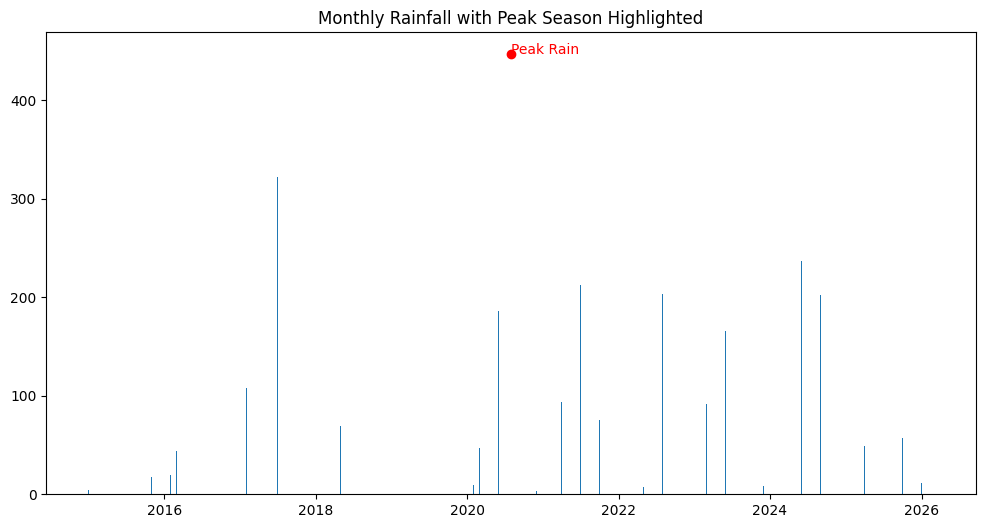

In [170]:
# Indentify the month with the highest rainful
peak = monthly_rain.loc[monthly_rain["PRECTOTCORR"].idxmax()]

plt.figure(figsize=(12,6))
plt.bar(monthly_rain["YearMonth"], monthly_rain["PRECTOTCORR"])

plt.scatter(peak["YearMonth"], peak["PRECTOTCORR"], color="red")
plt.text(peak["YearMonth"], peak["PRECTOTCORR"], "Peak Rain", color="red")

plt.title("Monthly Rainfall with Peak Season Highlighted")
plt.show()

In [172]:
# correlation analysis
numeric_df = df.select_dtypes(include=["number"])

corr_matrix = numeric_df.corr()
corr_matrix

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
YEAR,1.000000,-0.051255,0.048777,0.009346,0.065727,-0.038116,0.039607,0.050529,-0.054520,-0.064972,-0.099459,0.069982,-0.051487
DOY,-0.051255,1.000000,-0.522203,-0.535849,-0.234453,-0.225868,0.074874,0.425409,-0.193956,-0.180514,0.074646,0.194453,0.996557
T2M,0.048777,-0.522203,1.000000,0.654631,0.724802,-0.023172,0.009186,-0.194146,-0.069825,-0.014458,-0.184556,0.225977,-0.523585
T2M_MAX,0.009346,-0.535849,0.654631,1.000000,-0.016274,0.731151,-0.444728,-0.792422,0.381629,0.351070,-0.027113,-0.524355,-0.536378
T2M_MIN,0.065727,-0.234453,0.724802,-0.016274,1.000000,-0.694024,0.411149,0.441994,-0.391412,-0.290063,-0.214517,0.753414,-0.235851
T2M_RANGE,-0.038116,-0.225868,-0.023172,0.731151,-0.694024,1.000000,-0.600755,-0.872156,0.541854,0.450699,0.126844,-0.891619,-0.225294
PRECTOTCORR,0.039607,0.074874,0.009186,-0.444728,0.411149,-0.600755,1.000000,0.501347,-0.390109,-0.334508,-0.096233,0.517625,0.075529
RH2M,0.050529,0.425409,-0.194146,-0.792422,0.441994,-0.872156,0.501347,1.000000,-0.444068,-0.380345,-0.047753,0.904901,0.424594
WS2M,-0.054520,-0.193956,-0.069825,0.381629,-0.391412,0.541854,-0.390109,-0.444068,1.000000,0.940826,0.170016,-0.511268,-0.192180
WS2M_MAX,-0.064972,-0.180514,-0.014458,0.351070,-0.290063,0.450699,-0.334508,-0.380345,0.940826,1.000000,0.161582,-0.422243,-0.177898


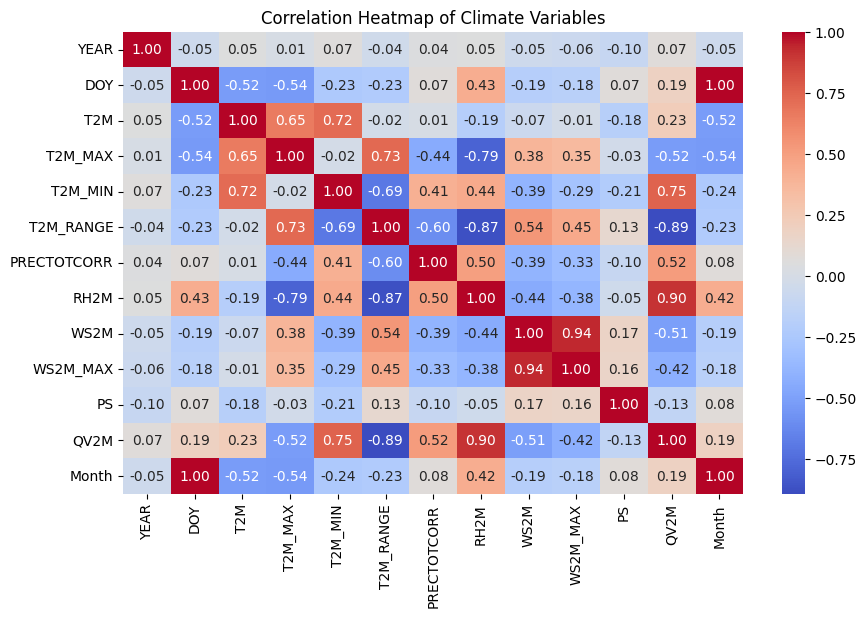

In [173]:
# plotting the correlation heatmap
plt.figure(figsize=(10,6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Climate Variables")
plt.show()

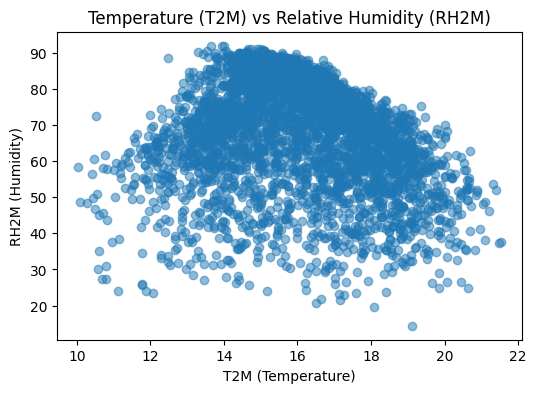

In [174]:
# sactter plot of T2M VS RH2M
plt.figure(figsize=(6,4))

plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)

plt.title("Temperature (T2M) vs Relative Humidity (RH2M)")
plt.xlabel("T2M (Temperature)")
plt.ylabel("RH2M (Humidity)")

plt.show()

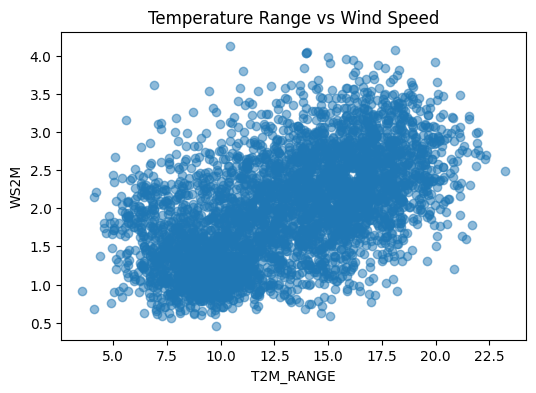

In [175]:
# scatter plot of T2M_RANGE vs WS2M
df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

plt.figure(figsize=(6,4))

plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)

plt.title("Temperature Range vs Wind Speed")
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")

plt.show()

In [ ]:
# Indetify the strongest correlations
corr_pairs = corr_matrix.unstack()

# Remove self-correlation
corr_pairs = corr_pairs[corr_pairs != 1]

# Sort by absolute strength
top_corr = corr_pairs.abs().sort_values(ascending=False)

top_corr.head(10)

DOY        Month        0.996557
Month      DOY          0.996557
WS2M       WS2M_MAX     0.940826
WS2M_MAX   WS2M         0.940826
RH2M       QV2M         0.904901
QV2M       RH2M         0.904901
T2M_RANGE  QV2M         0.891619
QV2M       T2M_RANGE    0.891619
T2M_RANGE  RH2M         0.872156
RH2M       T2M_RANGE    0.872156
dtype: float64

In [177]:
# Get the top 3 unique variable pairs with the strongest correlations
top3 = top_corr[~top_corr.index.duplicated()].head(3)
top3

DOY    Month       0.996557
Month  DOY         0.996557
WS2M   WS2M_MAX    0.940826
dtype: float64

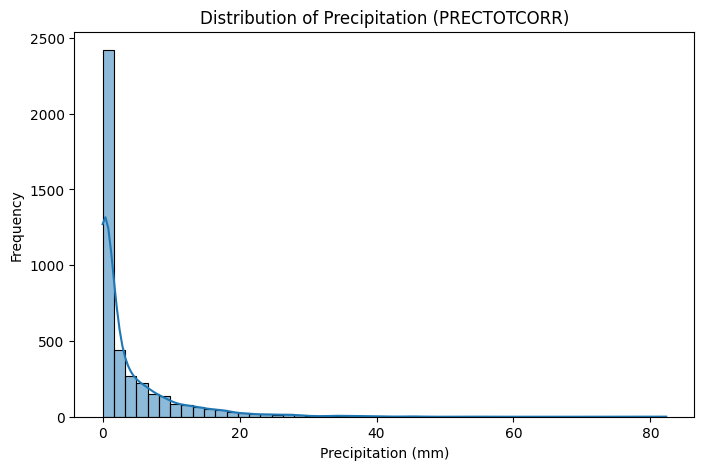

In [178]:
# Distribution of precipitation 
plt.figure(figsize=(8,5))

sns.histplot(df["PRECTOTCORR"], bins=50, kde=True)

plt.title("Distribution of Precipitation (PRECTOTCORR)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Skewness of the precipitation distribution
df["PRECTOTCORR"].skew()

np.float64(3.174521393838088)

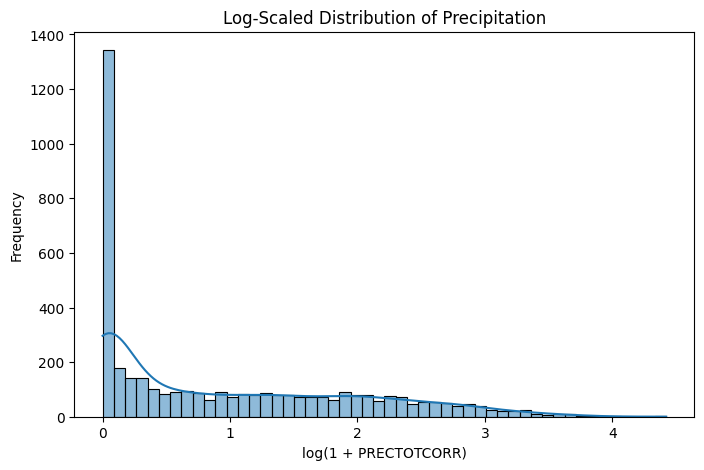

In [180]:
# Log-Scaled Dostribution of precipitation
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df["PRECTOTCORR"]), bins=50, kde=True)

plt.title("Log-Scaled Distribution of Precipitation")
plt.xlabel("log(1 + PRECTOTCORR)")
plt.ylabel("Frequency")

plt.show()

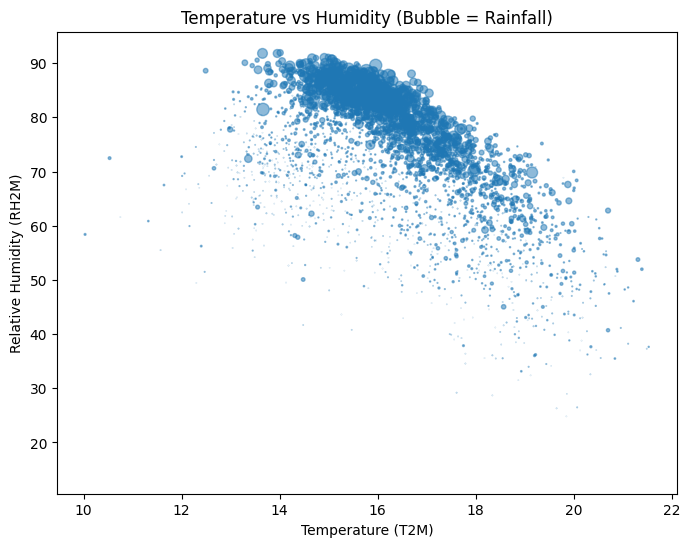

In [181]:
# Bubble plot of T2M vs RH2M with PRECTOTCORR as bubble size
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2,   # scale bubble size
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")

plt.show()

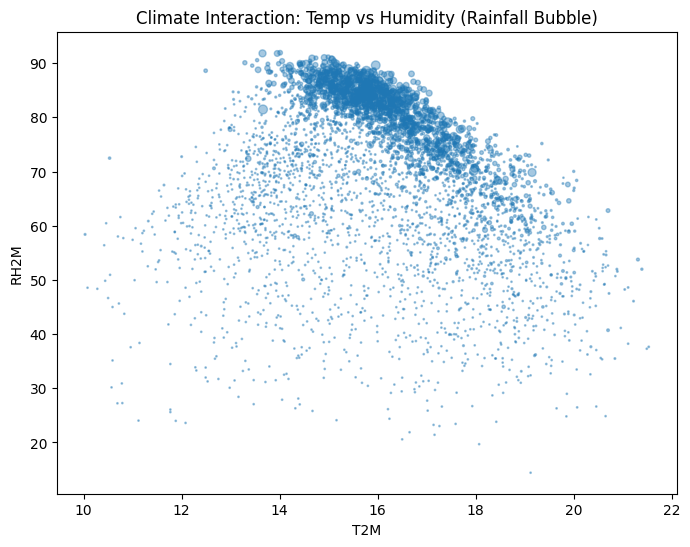

In [182]:
# To avoid excessively large bubbles, we can normalize the bubble size
bubble_size = (df["PRECTOTCORR"] - df["PRECTOTCORR"].min()) + 1

plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=bubble_size,
    alpha=0.4
)

plt.title("Climate Interaction: Temp vs Humidity (Rainfall Bubble)")
plt.xlabel("T2M")
plt.ylabel("RH2M")

plt.show()